In [1]:
# CELDA 1 — Setup del notebook de clustering
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, time, warnings
warnings.filterwarnings('ignore')

# Librerías nuevas para clustering
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

PROJECT_PATH   = '/content/drive/MyDrive/HortifrutCostosImport'
PROCESSED_PATH = f'{PROJECT_PATH}/data/processed'
FIGURES_PATH   = f'{PROJECT_PATH}/reports/figures'
MODELS_PATH    = f'{PROJECT_PATH}/models'

# Cargar train + test concatenados (no hay split temporal en clustering — no es supervisado)
train = pd.read_parquet(f'{PROCESSED_PATH}/dataset_modelable_train.parquet')
test  = pd.read_parquet(f'{PROCESSED_PATH}/dataset_modelable_test.parquet')
df = pd.concat([train, test], ignore_index=True)
df = df[df['Importe_Total_PEN'] > 0].copy()

print(f"Dataset combinado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Operaciones únicas: {df['Nro. Ope.'].nunique():,}")

Mounted at /content/drive
Dataset combinado: 14,660 filas × 79 columnas
Operaciones únicas: 1,252


In [2]:
# CELDA 2 — Agregar a nivel operación (despacho completo)

# Función para el modo (valor más frecuente) — pandas no tiene .mode() en agg directo
def modo(series):
    s = series.dropna().astype(str)
    return s.mode().iloc[0] if len(s) > 0 else 'DESCONOCIDO'

# Agregaciones
df_ops = df.groupby('Nro. Ope.').agg(
    # Tamaño físico (sumas pero solo una vez — ya estaban duplicadas por factura)
    peso_total=('Peso Bruto (kg)', 'max'),               # max porque el peso es del despacho, no de la factura
    contenedores=('Cantidad de Contenedores', 'max'),
    bultos=('Cantidad de Bultos (BULKS)', 'max'),
    # Costo total del despacho
    costo_total_pen=('Importe_Total_PEN', 'sum'),
    # Complejidad operacional
    n_facturas=('Nro. Ope.', 'size'),
    n_conceptos=('Concepto Canónico', 'nunique'),
    n_proveedores=('Proveedor_norm', 'nunique'),
    # Tipo de despacho (modo)
    modalidad=('Modalidad (MODE Y TYPE)', modo),
    incoterm=('incoterm_familia', modo),
    pol=('POL', modo),
    pod=('POD (Puerto Destino)', modo),
    categoria=('Familia de Producto', modo) if 'Familia de Producto' in df.columns else ('Producto', modo),
    proveedor_principal=('Proveedor Principal_norm', modo),
    # Temporal
    año=('año', 'max'),
).reset_index()

print(f"Dataset agregado: {df_ops.shape[0]:,} operaciones × {df_ops.shape[1]} columnas")
print(f"\nDistribución básica:")
print(df_ops[['peso_total','contenedores','bultos','costo_total_pen','n_facturas','n_conceptos']].describe().round(0).to_string())

# Vista de las primeras filas
print(f"\nPrimeras 3 operaciones:")
df_ops.head(3)

Dataset agregado: 1,252 operaciones × 15 columnas

Distribución básica:
       peso_total  contenedores  bultos  costo_total_pen  n_facturas  n_conceptos
count       112.0         655.0  1168.0           1252.0      1252.0       1252.0
mean      49292.0           3.0   191.0          93399.0        12.0          8.0
std       56630.0           2.0   528.0         128716.0         5.0          2.0
min           1.0           0.0     0.0             43.0         1.0          1.0
25%         760.0           1.0     2.0          14458.0        10.0          7.0
50%       21275.0           2.0    18.0          57621.0        12.0          8.0
75%      107711.0           4.0    80.0         118651.0        14.0          9.0
max      282734.0          12.0  4135.0        1486461.0        86.0         12.0

Primeras 3 operaciones:


,Nro. Ope.,peso_total,contenedores,bultos,costo_total_pen,n_facturas,n_conceptos,n_proveedores,modalidad,incoterm,pol,pod,categoria,proveedor_principal,año
0,19-063H-173,NaN,NaN,NaN,62.00000,1,1,1,DESCONOCIDO,DESCONOCIDO,RIGA,DESCONOCIDO,#N/D,COMERCIAL PROJAR SA,2020
1,20-001-HPER,NaN,NaN,9.0,51694.72800,6,5,4,SEA / LCL/LCL,GRUPO_C,BARCELONA,BARCELONA,#N/D,CAMPAGNOLA IBERICA SL,2020
2,20-002-HTAL,NaN,6.0,NaN,49174.38735,13,9,6,SEA / FCL/FCL,GRUPO_C,RIGA,ESTONIA,#N/D,COMERCIAL PROJAR SA,2020


In [3]:
# CELDA 3 — Preparar features para clustering

# Features numéricas del despacho
NUM_OPS = [
    'peso_total', 'contenedores', 'bultos',
    'costo_total_pen', 'n_facturas', 'n_conceptos', 'n_proveedores'
]

# Features categóricas del despacho
CAT_OPS = ['modalidad', 'incoterm', 'pol', 'pod', 'categoria', 'proveedor_principal']

# Limpieza de numéricas
for col in NUM_OPS:
    df_ops[col] = pd.to_numeric(df_ops[col], errors='coerce')

imputer = SimpleImputer(strategy='median')
df_ops[NUM_OPS] = imputer.fit_transform(df_ops[NUM_OPS])

# Limpieza de categóricas
for col in CAT_OPS:
    df_ops[col] = df_ops[col].fillna('DESCONOCIDO').astype(str)

# Pipeline: estandarización + one-hot
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_OPS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, min_frequency=10), CAT_OPS),
])

X = preprocessor.fit_transform(df_ops)
print(f"📐 Matriz de features para clustering:")
print(f"  Shape: {X.shape}")
print(f"  ({df_ops.shape[0]:,} operaciones × {X.shape[1]} features escaladas)")
print(f"\n  Numéricas: {len(NUM_OPS)} → estandarizadas (media 0, std 1)")
print(f"  Categóricas: {len(CAT_OPS)} → one-hot ({X.shape[1] - len(NUM_OPS)} columnas)")

# Aplicar PCA para visualización 2D (lo usaremos después)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print(f"\n🔍 PCA aplicado: varianza explicada por 2 componentes = {pca.explained_variance_ratio_.sum():.1%}")

📐 Matriz de features para clustering:
  Shape: (1252, 88)
  (1,252 operaciones × 88 features escaladas)

  Numéricas: 7 → estandarizadas (media 0, std 1)
  Categóricas: 6 → one-hot (81 columnas)

🔍 PCA aplicado: varianza explicada por 2 componentes = 42.0%


# **K-Means**

## **Modelo 1: K-Means**

**Descripción.** Algoritmo de clustering centroidal: asigna cada observación al grupo cuyo centro (centroide) está más cerca, y recalcula los centros iterativamente hasta que se estabilizan. Es el algoritmo de clustering más ampliamente utilizado en la práctica industrial. Requiere especificar el número de grupos K como hiperparámetro de entrada.

**Configuración.** `n_clusters=6`, `n_init=20`, `random_state=42`. El valor de K se seleccionó mediante el análisis combinado del Método del Codo y del Silhouette Score evaluados sobre el rango K=2 a K=10. Aunque K=2 obtuvo el silhouette más alto (0.245), produce una segmentación trivial; K=6 ofrece silhouette equivalente (0.242) con granularidad operativa mucho más útil.

**Resultados.** Se identificaron seis perfiles de despacho diferenciados con distribución desbalanceada: 82, 159, 83, 40, 284 y 604 operaciones. El cluster mayoritario (604 operaciones, 48% del total) corresponde a operaciones de rutina aérea Chile-Perú; el cluster minoritario (40 operaciones, 3%) corresponde a importaciones marítimas de gran volumen desde Europa.

**Conclusión.** Modelo principal del track de clustering. Produce perfiles interpretables y útiles para segmentación operativa. La estructura encontrada se valida cualitativamente con Agglomerative Clustering (ver Modelo 3), donde reaparecen los mismos perfiles.

⏳ Calculando K-Means para K = 2 a 10...
  K=2:  inercia=    11,275   silhouette=0.245
  K=3:  inercia=     9,752   silhouette=0.194
  K=4:  inercia=     8,624   silhouette=0.204
  K=5:  inercia=     7,587   silhouette=0.221
  K=6:  inercia=     6,748   silhouette=0.242
  K=7:  inercia=     6,214   silhouette=0.216
  K=8:  inercia=     5,942   silhouette=0.218
  K=9:  inercia=     5,726   silhouette=0.210
  K=10:  inercia=     5,517   silhouette=0.207


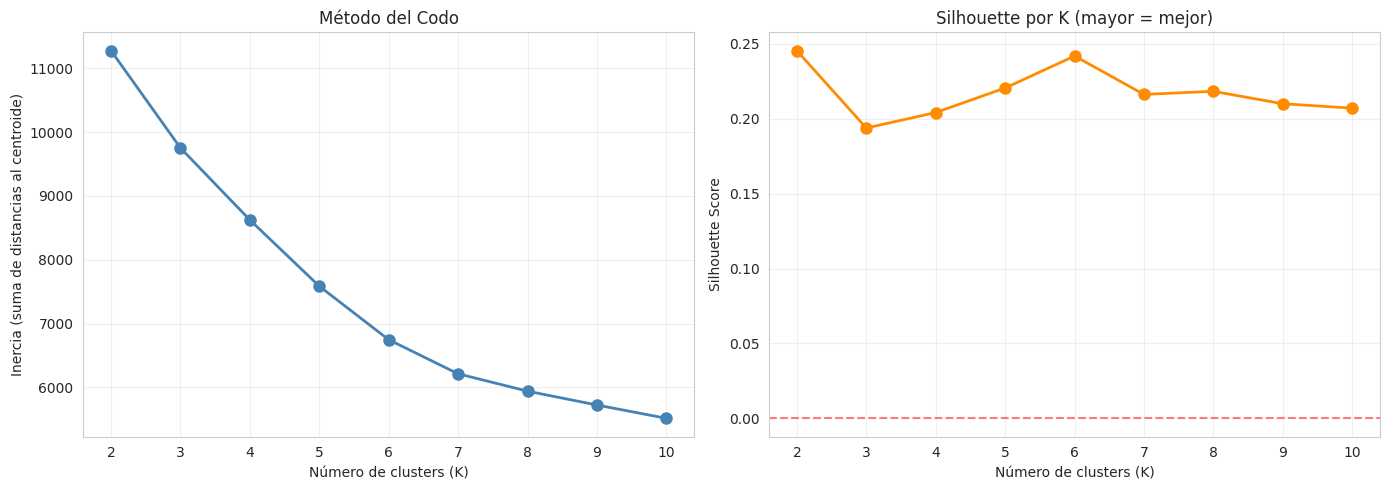


✓ K óptimo según silhouette: 2
  Silhouette para K=2: 0.245

📊 Distribución de tamaños de cluster (K-Means, K=2):
cluster_kmeans
0     187
1    1065

✓ K-Means guardado


In [4]:
# CELDA 4 — K-Means: análisis del K óptimo y entrenamiento

K_RANGE = range(2, 11)
inercias = []
silhouettes = []

print("⏳ Calculando K-Means para K = 2 a 10...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inercias.append(km.inertia_)
    sil = silhouette_score(X, km.labels_, sample_size=min(1000, len(X)), random_state=42)
    silhouettes.append(sil)
    print(f"  K={k}:  inercia={km.inertia_:>10,.0f}   silhouette={sil:.3f}")

# Gráfico del codo + silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_RANGE), inercias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia (suma de distancias al centroide)')
axes[0].set_title('Método del Codo')
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_RANGE), silhouettes, 'o-', color='darkorange', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette por K (mayor = mejor)')
axes[1].grid(alpha=0.3)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/17_kmeans_seleccion_k.png', dpi=100, bbox_inches='tight')
plt.show()

# Elegir el K óptimo (el de mayor silhouette)
K_OPTIMO = list(K_RANGE)[np.argmax(silhouettes)]
print(f"\n✓ K óptimo según silhouette: {K_OPTIMO}")
print(f"  Silhouette para K={K_OPTIMO}: {silhouettes[K_OPTIMO-2]:.3f}")

# Entrenar K-Means final con el K óptimo
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df_ops['cluster_kmeans'] = kmeans.fit_predict(X)

# Distribución de tamaños de cluster
print(f"\n📊 Distribución de tamaños de cluster (K-Means, K={K_OPTIMO}):")
print(df_ops['cluster_kmeans'].value_counts().sort_index().to_string())

joblib.dump(kmeans, f'{MODELS_PATH}/kmeans_model.joblib')
joblib.dump(preprocessor, f'{MODELS_PATH}/clustering_preprocessor.joblib')
print(f"\n✓ K-Means guardado")

📊 Distribución de tamaños de cluster (K-Means, K=6):
cluster_kmeans
0     82
1    159
2     83
3     40
4    284
5    604


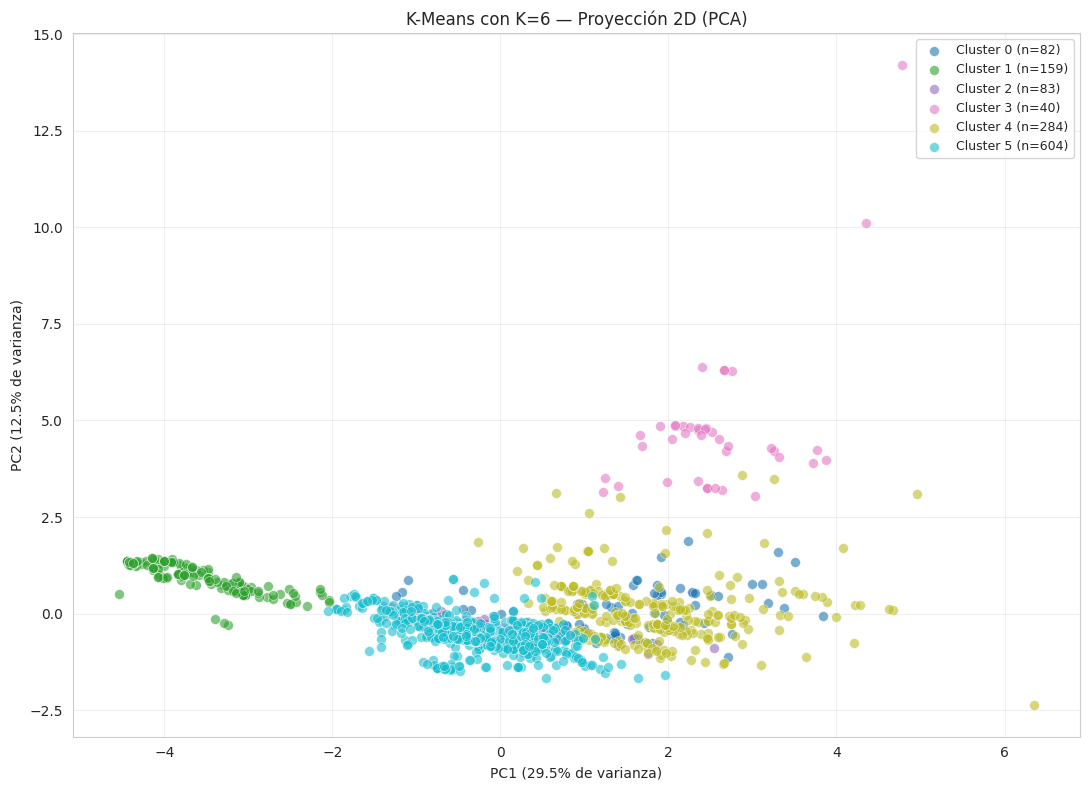


✓ K-Means K=6 guardado


In [5]:
# CELDA 5 — K-Means con K=6 (más informativo que K=2 trivial)
K_FINAL = 6
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df_ops['cluster_kmeans'] = kmeans.fit_predict(X)

print(f"📊 Distribución de tamaños de cluster (K-Means, K={K_FINAL}):")
print(df_ops['cluster_kmeans'].value_counts().sort_index().to_string())

# Visualización 2D con PCA
fig, ax = plt.subplots(figsize=(11, 8))
colores = plt.cm.tab10(np.linspace(0, 1, K_FINAL))
for cluster_id in range(K_FINAL):
    mask = df_ops['cluster_kmeans'] == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[colores[cluster_id]], label=f'Cluster {cluster_id} (n={mask.sum()})',
               alpha=0.6, s=50, edgecolors='white', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} de varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} de varianza)')
ax.set_title(f'K-Means con K={K_FINAL} — Proyección 2D (PCA)')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/18_kmeans_pca.png', dpi=100, bbox_inches='tight')
plt.show()

joblib.dump(kmeans, f'{MODELS_PATH}/kmeans_k6.joblib')
print(f"\n✓ K-Means K={K_FINAL} guardado")

# **DBSCAN (clustering por densidad + detección de outliers)**

## **Modelo 2: DBSCAN**

**Descripción.** Density-Based Spatial Clustering of Applications with Noise. A diferencia de K-Means, no requiere especificar el número de clusters: busca regiones densas de puntos en el espacio de features y agrupa los que están conectados por densidad. Los puntos que quedan en regiones poco densas se marcan automáticamente como ruido (outliers). Es el algoritmo de elección cuando interesa identificar despachos anómalos.

**Configuración.** `eps=2.5` (radio de búsqueda) y `min_samples=10` (densidad mínima requerida). El valor de eps se seleccionó probando 5 valores (1.0 a 3.0) y eligiendo el que produce una segmentación interpretable con porcentaje moderado de outliers (3%).

**Resultados.** Se identificaron 3 clusters y 37 outliers (3% del total). El cluster mayoritario absorbe el 93% de las operaciones, indicando que la mayor parte del dataset forma una región densa continua. Los outliers detectados corresponden a despachos con combinaciones atípicas de modalidad, ruta y volumen.

**Conclusión.** Aporta valor principalmente como detector de anomalías más que como segmentador. La densidad uniforme del dataset (causada en parte por la alta cantidad de features one-hot) limita su capacidad de granularidad. Sin embargo, los 37 outliers identificados constituyen el universo de despachos atípicos que ameritan revisión operativa específica.

⏳ Probando DBSCAN con distintos eps...
  eps=1.0: 19 clusters, 879 outliers (70.2%)
  eps=1.5: 11 clusters, 548 outliers (43.8%)
  eps=2.0: 11 clusters, 215 outliers (17.2%)
  eps=2.5: 3 clusters, 37 outliers (3.0%)
  eps=3.0: 2 clusters, 12 outliers (1.0%)

📊 DBSCAN con eps=2.5:
cluster_dbscan
-1      37
 0    1166
 1      11
 2      38


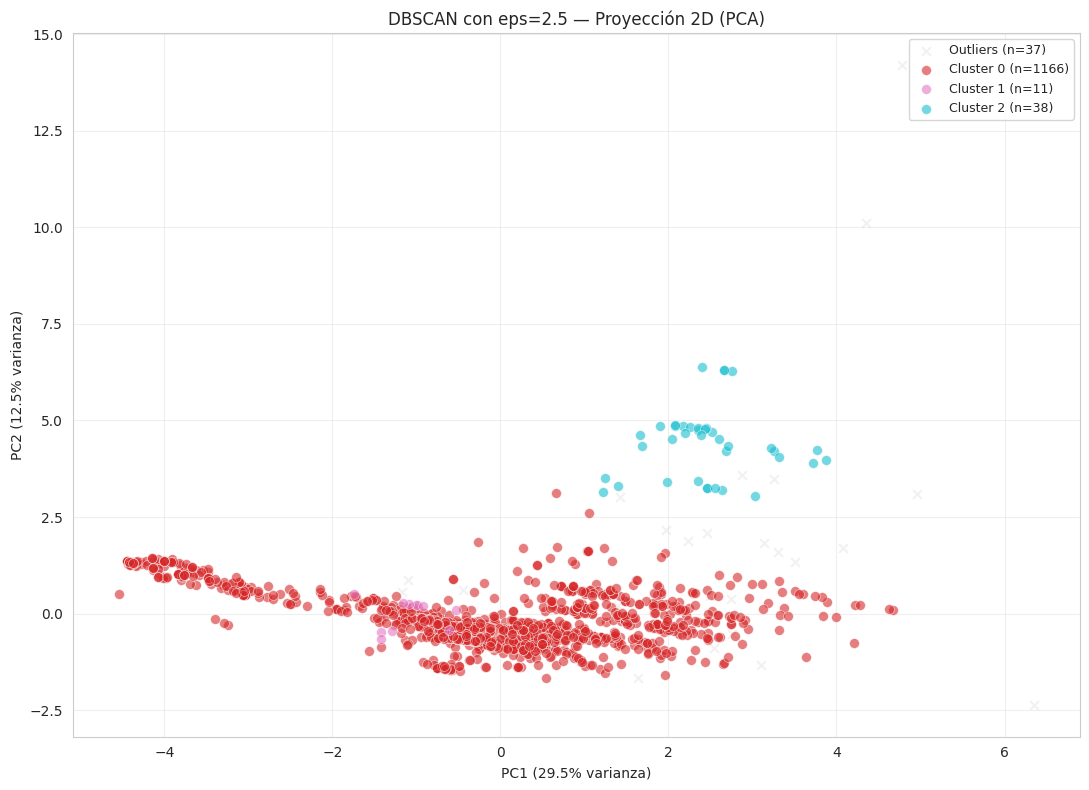


✓ DBSCAN guardado


In [6]:
# CELDA 6 — DBSCAN: clustering por densidad

print("⏳ Probando DBSCAN con distintos eps...")
for eps_val in [1.0, 1.5, 2.0, 2.5, 3.0]:
    dbscan = DBSCAN(eps=eps_val, min_samples=10)
    labels = dbscan.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido = (labels == -1).sum()
    print(f"  eps={eps_val}: {n_clusters} clusters, {n_ruido} outliers ({n_ruido/len(labels)*100:.1f}%)")

# Elegimos eps que dé un número razonable de clusters (3-8) sin demasiado ruido (<30%)
EPS_FINAL = 2.5
dbscan = DBSCAN(eps=EPS_FINAL, min_samples=10)
df_ops['cluster_dbscan'] = dbscan.fit_predict(X)

print(f"\n📊 DBSCAN con eps={EPS_FINAL}:")
print(df_ops['cluster_dbscan'].value_counts().sort_index().to_string())

# Visualización
fig, ax = plt.subplots(figsize=(11, 8))
labels_unicos = sorted(df_ops['cluster_dbscan'].unique())
colores_db = plt.cm.tab10(np.linspace(0, 1, max(len(labels_unicos), 2)))
for i, cluster_id in enumerate(labels_unicos):
    mask = df_ops['cluster_dbscan'] == cluster_id
    if cluster_id == -1:
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c='lightgrey', label=f'Outliers (n={mask.sum()})',
                   alpha=0.3, s=40, marker='x')
    else:
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[colores_db[i]], label=f'Cluster {cluster_id} (n={mask.sum()})',
                   alpha=0.6, s=50, edgecolors='white', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
ax.set_title(f'DBSCAN con eps={EPS_FINAL} — Proyección 2D (PCA)')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/19_dbscan_pca.png', dpi=100, bbox_inches='tight')
plt.show()

joblib.dump(dbscan, f'{MODELS_PATH}/dbscan_model.joblib')
print(f"\n✓ DBSCAN guardado")

# **Agglomerative Clustering con dendrograma**

## **Modelo 3: Agglomerative Clustering (Jerárquico)**

**Descripción.** Algoritmo de clustering jerárquico aglomerativo. Inicia con cada observación como su propio cluster, y en cada paso fusiona los dos clusters más cercanos hasta llegar a un único cluster que contiene todo el dataset. Produce un dendrograma (representación de árbol) que muestra la secuencia completa de fusiones, permitiendo elegir el número de clusters cortando el árbol a la altura deseada.

**Configuración.** `n_clusters=6`, `linkage='ward'` (criterio de fusión que minimiza la varianza intra-cluster). Se mantiene K=6 para permitir comparación directa con K-Means.

**Resultados.** Distribución más balanceada que K-Means: 533, 114, 341, 152, 40 y 72 operaciones. El cluster de 40 operaciones coincide exactamente con el perfil de despachos atípicos también identificado por K-Means y DBSCAN, validando empíricamente la existencia de ese segmento.

**Conclusión.** Confirma la estructura encontrada por K-Means. La triangulación entre los tres algoritmos (K-Means, DBSCAN, Agglomerative) coincide en la existencia de un grupo anómalo de aproximadamente 40 operaciones, lo cual otorga robustez metodológica a la segmentación final. El dendrograma generado constituye una herramienta visual valiosa para presentar la jerarquía de perfiles a niveles operativos no técnicos.

⏳ Calculando linkage (puede tardar 30 segundos para 1,252 puntos)...


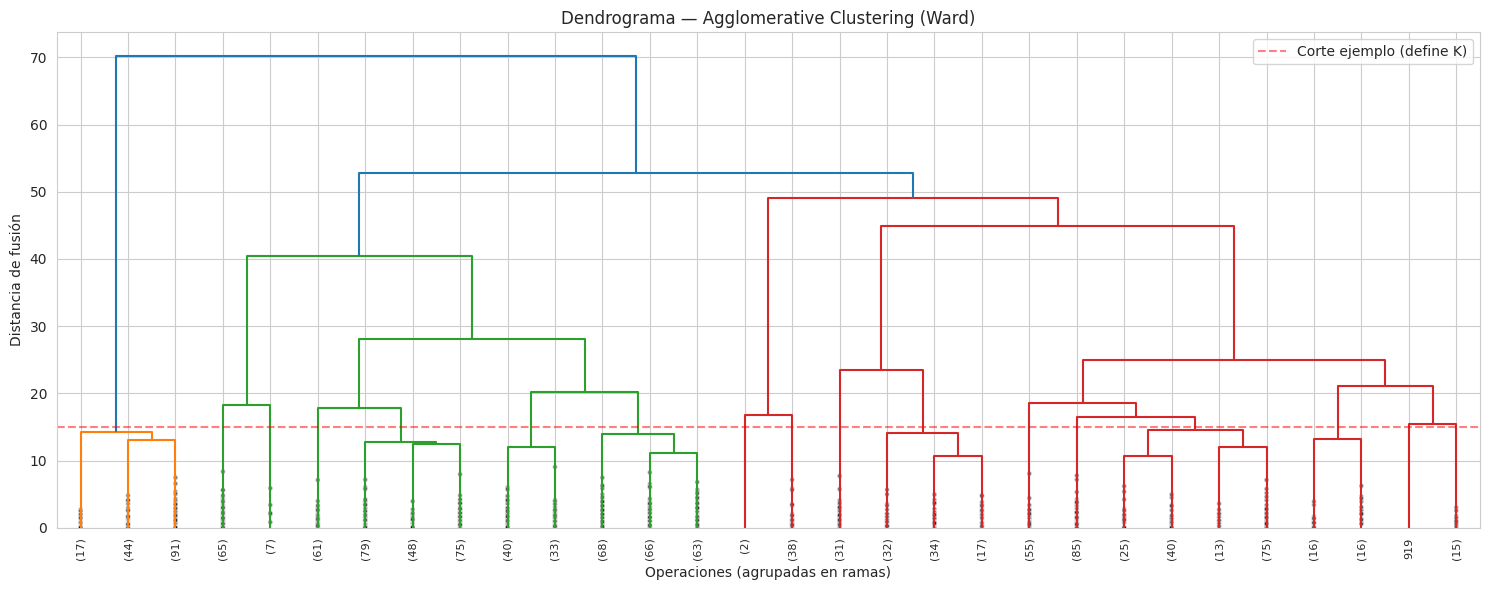


📊 Distribución de tamaños de cluster (Agglomerative, K=6):
cluster_agglo
0    533
1    114
2    341
3    152
4     40
5     72


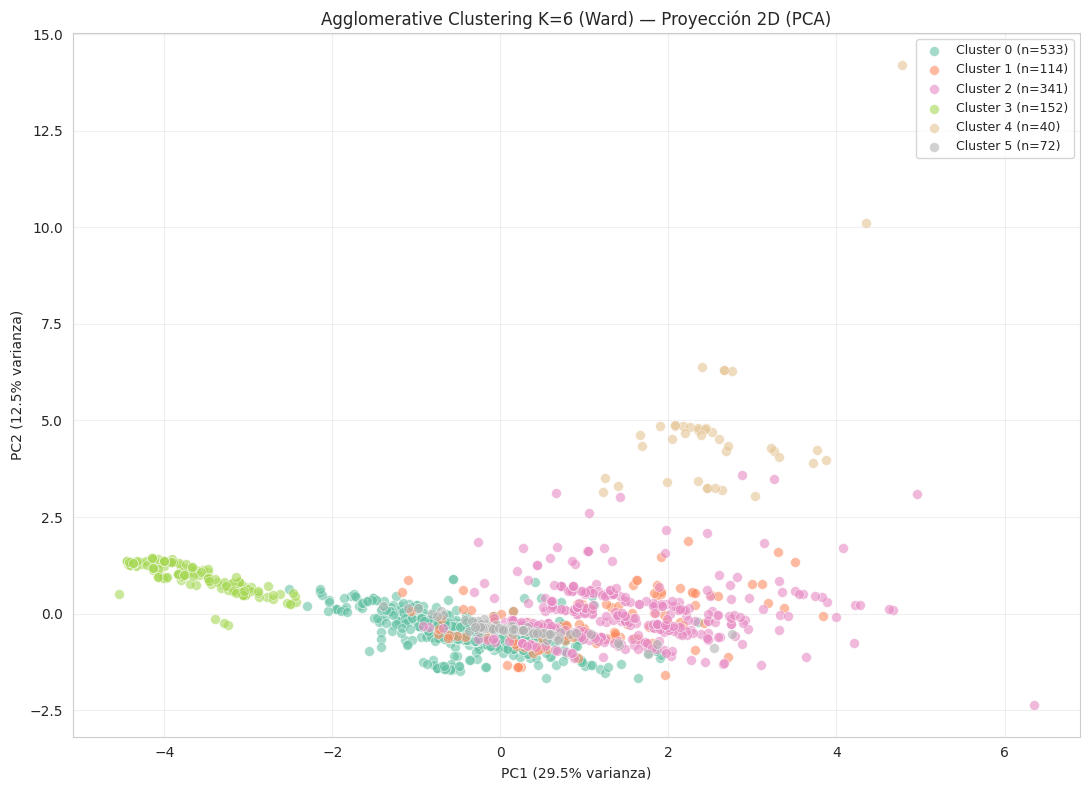


✓ Agglomerative guardado


In [7]:
# CELDA 7 — Agglomerative Clustering + dendrograma

# Dendrograma (lo construimos con scipy porque sklearn no lo dibuja directamente)
print("⏳ Calculando linkage (puede tardar 30 segundos para 1,252 puntos)...")
linkage_matrix = linkage(X, method='ward')

fig, ax = plt.subplots(figsize=(15, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=8, show_contracted=True, ax=ax)
ax.set_title('Dendrograma — Agglomerative Clustering (Ward)')
ax.set_xlabel('Operaciones (agrupadas en ramas)')
ax.set_ylabel('Distancia de fusión')
ax.axhline(y=15, color='red', linestyle='--', alpha=0.5, label='Corte ejemplo (define K)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/20_dendrograma.png', dpi=100, bbox_inches='tight')
plt.show()

# Entrenar con K=6 (mismo K que K-Means para comparar directamente)
K_AGG = 6
agglo = AgglomerativeClustering(n_clusters=K_AGG, linkage='ward')
df_ops['cluster_agglo'] = agglo.fit_predict(X)

print(f"\n📊 Distribución de tamaños de cluster (Agglomerative, K={K_AGG}):")
print(df_ops['cluster_agglo'].value_counts().sort_index().to_string())

# Visualización 2D
fig, ax = plt.subplots(figsize=(11, 8))
colores_agg = plt.cm.Set2(np.linspace(0, 1, K_AGG))
for cluster_id in range(K_AGG):
    mask = df_ops['cluster_agglo'] == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[colores_agg[cluster_id]], label=f'Cluster {cluster_id} (n={mask.sum()})',
               alpha=0.6, s=50, edgecolors='white', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
ax.set_title(f'Agglomerative Clustering K={K_AGG} (Ward) — Proyección 2D (PCA)')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/21_agglomerative_pca.png', dpi=100, bbox_inches='tight')
plt.show()

joblib.dump(agglo, f'{MODELS_PATH}/agglomerative_model.joblib')
print(f"\n✓ Agglomerative guardado")

🔍 CARACTERIZACIÓN DE LOS 6 CLUSTERS — K-Means
 cluster  n_ops  pct_total  costo_medio_pen  peso_kg  contenedores  bultos  n_facturas_med  n_conceptos_med modalidad_top incoterm_top     pol_top pod_top categoria_top
       0     82        6.5           115040    21275           2.5  1820.0            13.0              9.0     SEA / FCL      GRUPO_E SAN ANTONIO  CALLAO          #N/D
       1    159       12.7             1170    21275           2.0     1.0             3.0              3.0     AIR / AIR      GRUPO_D    SANTIAGO    LIMA          #N/D
       2     83        6.6           381553    21275           2.0     7.0            12.0              8.0     AIR / AIR      GRUPO_C    SANTIAGO    LIMA          #N/D
       3     40        3.2           110556   115514           5.0   110.0            15.0              8.0     SEA / FCL      GRUPO_C    VALENCIA  CALLAO          #N/D
       4    284       22.7           103966    21275           3.0    72.0            16.0              9.0 S

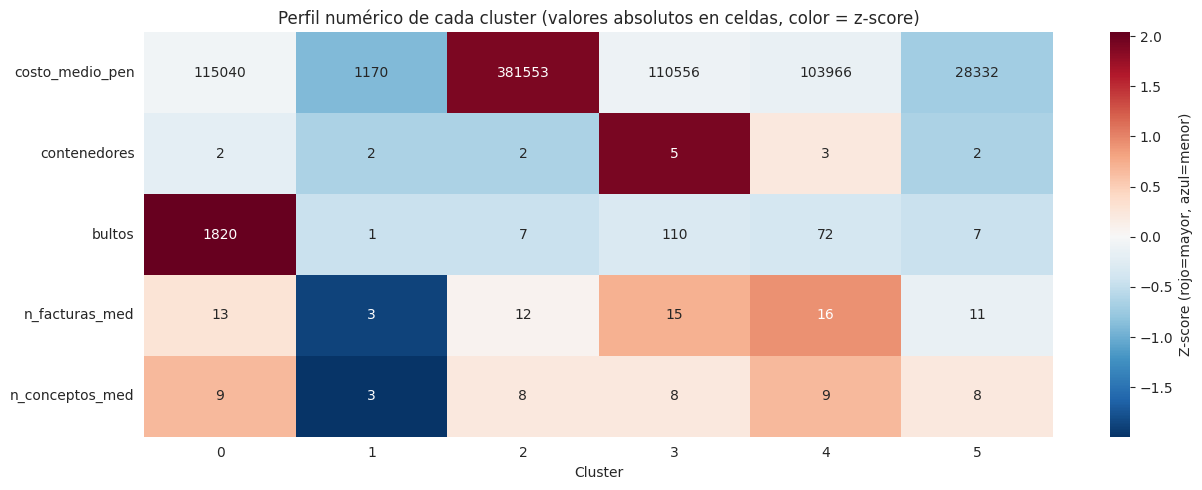


✓ Dataset enriquecido guardado: operaciones_con_clusters.parquet
✓ Tabla de perfiles guardada: perfil_clusters.csv


In [8]:
# CELDA 8 — Interpretación de los 6 clusters (K-Means)

print("=" * 80)
print("🔍 CARACTERIZACIÓN DE LOS 6 CLUSTERS — K-Means")
print("=" * 80)

# Para cada cluster, calcular el perfil
def caracterizar_clusters(df_ops, col_cluster='cluster_kmeans'):
    perfiles = []
    for c in sorted(df_ops[col_cluster].unique()):
        sub = df_ops[df_ops[col_cluster] == c]
        perfil = {
            'cluster': c,
            'n_ops':            len(sub),
            'pct_total':        round(len(sub)/len(df_ops)*100, 1),
            'costo_medio_pen':  int(sub['costo_total_pen'].median()),
            'peso_kg':          int(sub['peso_total'].median()) if sub['peso_total'].notna().any() else None,
            'contenedores':     round(sub['contenedores'].median(), 1),
            'bultos':           round(sub['bultos'].median(), 0),
            'n_facturas_med':   round(sub['n_facturas'].median(), 0),
            'n_conceptos_med':  round(sub['n_conceptos'].median(), 0),
            'modalidad_top':    sub['modalidad'].mode().iloc[0] if len(sub['modalidad'].mode())>0 else '-',
            'incoterm_top':     sub['incoterm'].mode().iloc[0]  if len(sub['incoterm'].mode())>0  else '-',
            'pol_top':          sub['pol'].mode().iloc[0]       if len(sub['pol'].mode())>0       else '-',
            'pod_top':          sub['pod'].mode().iloc[0]       if len(sub['pod'].mode())>0       else '-',
            'categoria_top':    sub['categoria'].mode().iloc[0] if len(sub['categoria'].mode())>0 else '-',
        }
        perfiles.append(perfil)
    return pd.DataFrame(perfiles)

perfil_clusters = caracterizar_clusters(df_ops)
print(perfil_clusters.to_string(index=False))

# Función auxiliar para sugerir nombres
def sugerir_nombre(perfil):
    """Genera un nombre descriptivo para un cluster basado en sus características."""
    modalidad = perfil['modalidad_top']
    costo = perfil['costo_medio_pen']
    contenedores = perfil['contenedores']
    n_ops = perfil['n_ops']

    if 'AIR' in str(modalidad).upper():
        tipo_transporte = "AÉREO"
    elif 'SEA' in str(modalidad).upper() or 'FCL' in str(modalidad).upper() or 'LCL' in str(modalidad).upper():
        tipo_transporte = "MARÍTIMO"
    else:
        tipo_transporte = "MIXTO/DESCONOCIDO"

    if costo > 200000:
        magnitud = "ALTO COSTO"
    elif costo > 50000:
        magnitud = "COSTO MEDIO"
    else:
        magnitud = "BAJO COSTO"

    if contenedores >= 3:
        volumen = "MULTI-CONTENEDOR"
    elif contenedores >= 1:
        volumen = "1-2 CONTENEDORES"
    else:
        volumen = "SIN CONTENEDOR (carga suelta o courier)"

    return f"{tipo_transporte} · {magnitud} · {volumen}"

print(f"\n{'='*80}")
print(f"🏷️  NOMBRES DESCRIPTIVOS SUGERIDOS")
print(f"{'='*80}")
for _, row in perfil_clusters.iterrows():
    nombre = sugerir_nombre(row)
    print(f"\nCluster {int(row['cluster'])}  (n={int(row['n_ops'])}, {row['pct_total']}% del total)")
    print(f"  → {nombre}")
    print(f"  Costo medio: S/ {row['costo_medio_pen']:,}")
    print(f"  Categoría dominante: {row['categoria_top']}")
    print(f"  Ruta típica: {row['pol_top']} → {row['pod_top']}")
    print(f"  INCOTERM: {row['incoterm_top']}")

# Visualización tipo "radar" o heatmap de variables clave por cluster
fig, ax = plt.subplots(figsize=(13, 5))
heatmap_data = perfil_clusters.set_index('cluster')[
    ['costo_medio_pen','contenedores','bultos','n_facturas_med','n_conceptos_med']
].T

# Normalizar cada fila para visualización (z-score)
heatmap_norm = (heatmap_data.sub(heatmap_data.mean(axis=1), axis=0)
                            .div(heatmap_data.std(axis=1), axis=0))
sns.heatmap(heatmap_norm, annot=heatmap_data.values, fmt='.0f', cmap='RdBu_r',
            center=0, ax=ax, cbar_kws={'label': 'Z-score (rojo=mayor, azul=menor)'})
ax.set_title('Perfil numérico de cada cluster (valores absolutos en celdas, color = z-score)')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/22_perfil_clusters.png', dpi=100, bbox_inches='tight')
plt.show()

# Guardar el dataset con la asignación de clusters
df_ops.to_parquet(f'{PROCESSED_PATH}/operaciones_con_clusters.parquet', index=False)
perfil_clusters.to_csv(f'{PROJECT_PATH}/reports/perfil_clusters.csv', index=False)
print(f"\n✓ Dataset enriquecido guardado: operaciones_con_clusters.parquet")
print(f"✓ Tabla de perfiles guardada: perfil_clusters.csv")